In [1]:
import pandas as pd
import os
import glob
from tqdm import tqdm
import cudf as cd
from numba import cuda
import time
import matplotlib.pyplot as plt


In [2]:
def transfer_times(data):
    times = []
    iterations = 10
    # print_gpu_memory_usage_pynvml(device_id=0)
    for i in range(iterations):
        cuda.synchronize()
        start_time = time.perf_counter()

        cudf_df = cd.DataFrame.from_pandas(data)

        cuda.synchronize()
        end_time = time.perf_counter()
        times.append(end_time - start_time)

        # print(type(cudf_df))
        # del cudf_df
    # print_gpu_memory_usage_pynvml(device_id=0)
    elapsed_time = sum(times) / iterations
    return elapsed_time * 1000

In [3]:
def ideal_transfer_time(data):
    memory_usage = data.memory_usage(deep=True).sum()
    memory_usage = memory_usage / 10**9
    ideal_time = memory_usage / 16  # bandwidith is 16GB/s
    # print(memory_usage)
    return ideal_time * 1000, memory_usage

In [4]:
import pynvml


def format_bytes(size):
    """Converts bytes to a human-readable format (GB, MB, KB)."""
    power = 2**10  # 1024
    n = 0
    power_labels = {0: "B", 1: "KB", 2: "MB", 3: "GB", 4: "TB"}
    while size > power and n < max(power_labels.keys()):
        size /= power
        n += 1
    return f"{size:.2f} {power_labels[n]}"


def print_gpu_memory_usage_pynvml(device_id=0):
    """Prints GPU memory usage using pynvml for a specific device."""
    try:
        pynvml.nvmlInit()
        handle = pynvml.nvmlDeviceGetHandleByIndex(device_id)
        mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)

        print(f"--- GPU Memory (Device {device_id}) via pynvml ---")
        print(f"Total : {format_bytes(mem_info.total)}")
        print(f"Used  : {format_bytes(mem_info.used)}")
        print(f"Free  : {format_bytes(mem_info.free)}")
        print(
            "-" * (len(f"Total : {format_bytes(mem_info.total)}") + 4)
        )  # Dynamic width

    except pynvml.NVMLError as error:
        print(f"Failed to get GPU memory info using pynvml: {error}")
        print("Ensure NVIDIA drivers are installed and pynvml is compatible.")
    finally:
        try:
            pynvml.nvmlShutdown()
        except pynvml.NVMLError:
            pass

In [ ]:
input_dir = "/home/jupyter/generated_dataframes"
file_pattern = os.path.join(input_dir, "*.parquet")
files = glob.glob(file_pattern)

results_list = []

for file in tqdm(files):
    if ".parquet" in file:
        data = pd.read_parquet(file)
        elapsed_time = transfer_times(data)
        ideal_time, memory_usage = ideal_transfer_time(data)
        # print(f"elapsed_time {elapsed_time} ms")
        # print(f"ideal_time {ideal_time} ms")
        # print(f"memory usage {memory_usage} GB")
        results_list.append(
            {
                "memory_usage": memory_usage,
                "elapsed_time": elapsed_time,
                "ideal_time": ideal_time,
                "n_cols": len(data.columns),
                "n_rows": len(data),
            }
        )
        del data

  8%|████████▊                                                                                                            | 758/10000 [01:48<31:42,  4.86it/s]

In [7]:
results_df = pd.DataFrame(results_list)

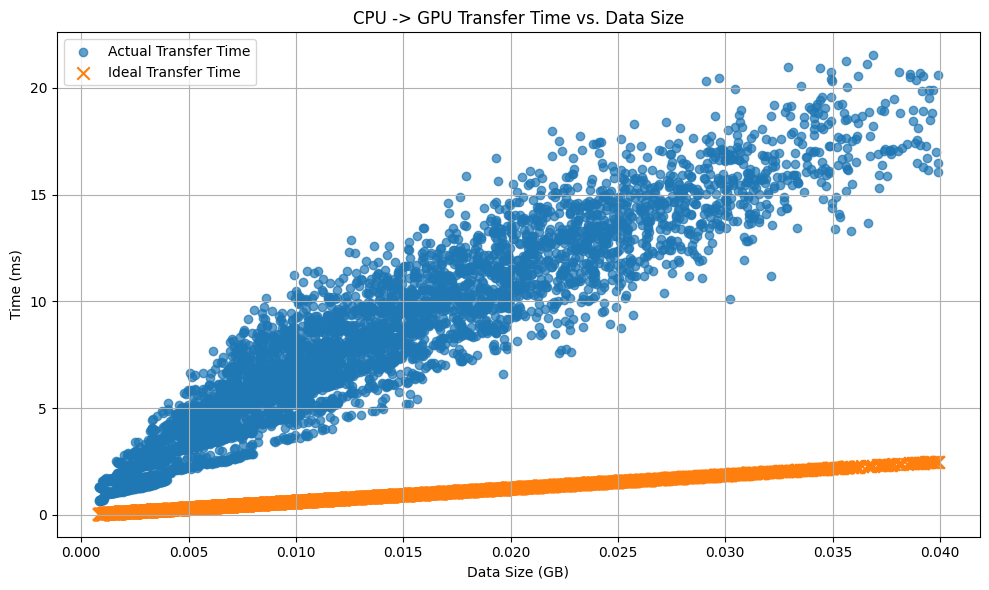

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(
    results_df_num["memory_usage"],
    results_df_num["elapsed_time"],
    label="Actual Transfer Time",
    alpha=0.7,
)
plt.scatter(
    results_df_num["memory_usage"],
    results_df_num["ideal_time"],
    label="Ideal Transfer Time",
    marker="x",
    s=80,
)
# Optional: Plot lines if data sizes are somewhat ordered
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['elapsed_time'], marker='o', linestyle='-', label='Actual Transfer Time')
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['ideal_time'], marker='x', linestyle='--', label='Ideal Transfer Time')
plt.xlabel("Data Size (GB)")
plt.ylabel("Time (ms)")
plt.title("CPU -> GPU Transfer Time vs. Data Size")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

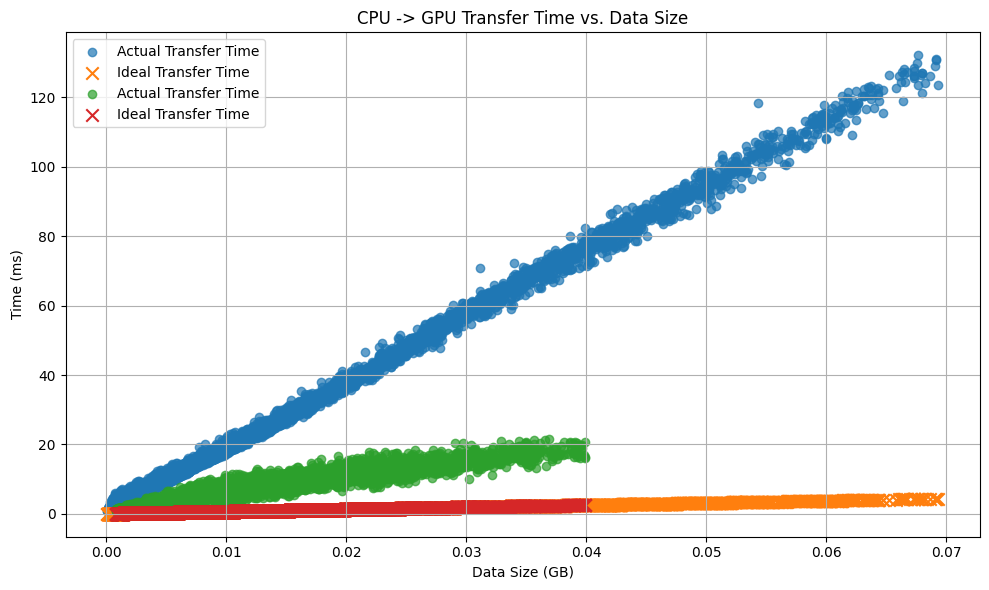

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["memory_usage"],
    results_df["elapsed_time"],
    label="Actual Transfer Time",
    alpha=0.7,
)
plt.scatter(
    results_df["memory_usage"],
    results_df["ideal_time"],
    label="Ideal Transfer Time",
    marker="x",
    s=80,
)
plt.scatter(
    results_df_num["memory_usage"],
    results_df_num["elapsed_time"],
    label="Actual Transfer Time",
    alpha=0.7,
)
plt.scatter(
    results_df_num["memory_usage"],
    results_df_num["ideal_time"],
    label="Ideal Transfer Time",
    marker="x",
    s=80,
)
# Optional: Plot lines if data sizes are somewhat ordered
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['elapsed_time'], marker='o', linestyle='-', label='Actual Transfer Time')
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['ideal_time'], marker='x', linestyle='--', label='Ideal Transfer Time')
plt.xlabel("Data Size (GB)")
plt.ylabel("Time (ms)")
plt.title("CPU -> GPU Transfer Time vs. Data Size")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

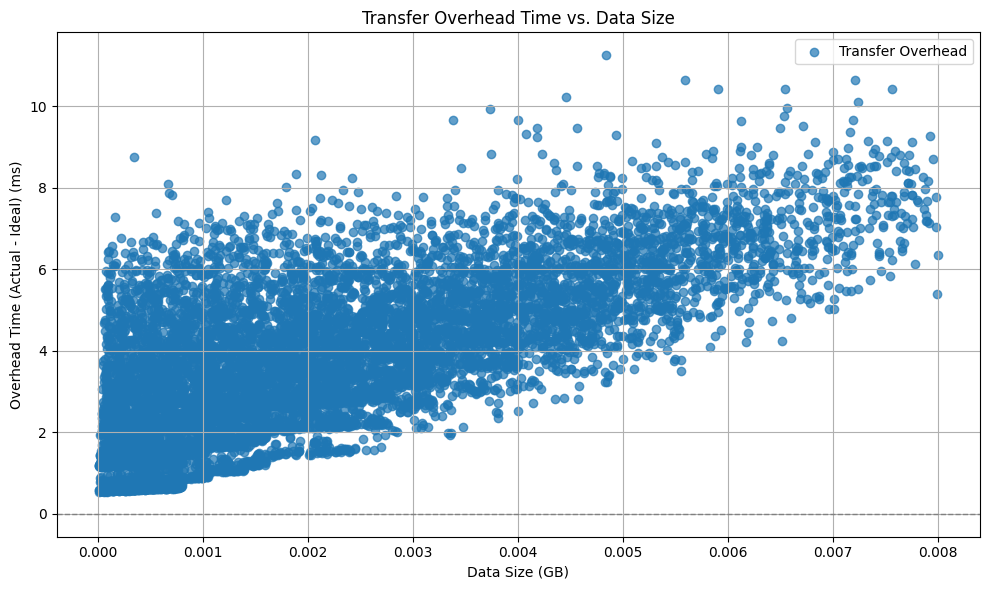

In [14]:
results_df["overhead_ms"] = results_df["elapsed_time"] - results_df["ideal_time"]
plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["memory_usage"],
    results_df["overhead_ms"],
    label="Transfer Overhead",
    alpha=0.7,
)
# Optional: Add a trend line if desired
# z = np.polyfit(results_df['memory_usage'], results_df['overhead_ms'], 1)
# p = np.poly1d(z)
# plt.plot(results_df['memory_usage'], p(results_df['memory_usage']), "r--", label=f'Trendline (y={z[0]:.2f}x+{z[1]:.2f})')
plt.xlabel("Data Size (GB)")
plt.ylabel("Overhead Time (Actual - Ideal) (ms)")
plt.title("Transfer Overhead Time vs. Data Size")
plt.axhline(0, color="grey", linestyle="--", lw=1)  # Zero overhead line
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Training set size: 8000
Testing set size: 2000

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 0.6590
  R-squared (R²): 0.8270


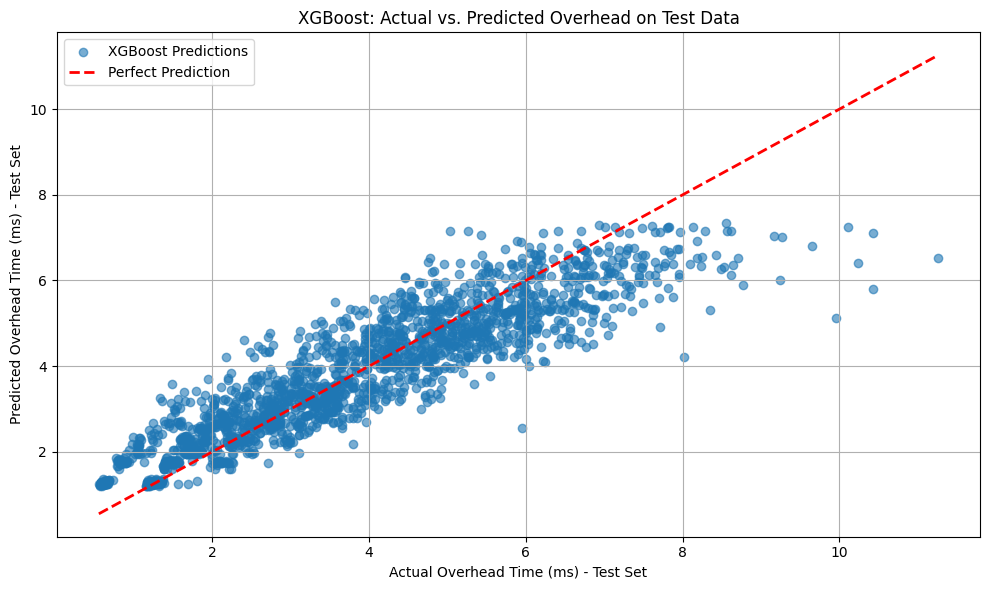

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# --- Assume results_df is already populated ---
# results_df = pd.DataFrame(results_list)
# results_df['overhead_ms'] = results_df['elapsed_time'] - results_df['ideal_time']
# ----------------------------------------------

if results_df.empty or "overhead_ms" not in results_df.columns:
    print(
        "Results DataFrame is empty or missing 'overhead_ms' column. Cannot train model."
    )
else:
    # 1. Prepare Data
    results_df_clean = results_df.dropna(subset=["memory_usage", "overhead_ms"])
    if results_df_clean.empty:
        print("No valid data points remain after removing NaNs.")
    else:
        X = results_df_clean[
            ["memory_usage", "n_cols", "n_rows"]
        ].values  # Feature (needs to be 2D)
        y = results_df_clean["overhead_ms"].values  # Target

        # --- IMPORTANT: Split data into Training and Testing sets ---
        # Use 80% for training, 20% for testing. random_state ensures reproducibility.
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"Training set size: {X_train.shape[0]}")
        print(f"Testing set size: {X_test.shape[0]}")

        # 2. Create and Configure the XGBoost Regressor Model
        # Common parameters:
        # n_estimators: Number of boosting rounds (trees)
        # learning_rate: Step size shrinkage to prevent overfitting
        # max_depth: Maximum depth of each tree
        # objective: Loss function ('reg:squarederror' for regression)
        # early_stopping_rounds: Stop training if validation score doesn't improve
        # random_state: For reproducibility
        xgb_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=20,  # Start with 100 trees, can tune this
            learning_rate=0.1,  # Common starting point
            max_depth=10,  # Shallow trees often work well initially
            subsample=0.8,  # Use 80% of data per tree (helps prevent overfitting)
            colsample_bytree=1.0,  # Use all features (only one here anyway)
            random_state=42,
            n_jobs=-1,  # Use all available CPU cores
        )

        # 3. Train the Model (with early stopping)
        # We use the test set as the evaluation set here for simplicity,
        # though a separate validation set is often preferred in rigorous workflows.
        print("\nTraining XGBoost model...")
        xgb_model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],  # Monitor performance on the test set
            verbose=False,  # Set to True to see training progress per round
        )
        print("Training complete.")

        # 4. Make Predictions on the Test Set
        y_pred_xgb = xgb_model.predict(X_test)

        # 5. Evaluate the Model on the Test Set
        mse_xgb = mean_squared_error(y_test, y_pred_xgb)
        r2_xgb = r2_score(y_test, y_pred_xgb)

        print("\n--- XGBoost Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE): {mse_xgb:.4f}")
        print(f"  R-squared (R²): {r2_xgb:.4f}")

        # Compare with Linear Model (if evaluated on the same test set - otherwise compare cautiously)
        # You might want to re-run the linear model evaluation on the *same* train/test split
        # from sklearn.linear_model import LinearRegression
        # linear_model_eval = LinearRegression()
        # linear_model_eval.fit(X_train, y_train)
        # y_pred_linear_test = linear_model_eval.predict(X_test)
        # mse_linear_test = mean_squared_error(y_test, y_pred_linear_test)
        # r2_linear_test = r2_score(y_test, y_pred_linear_test)
        # print(f"\n--- Linear Model Evaluation (on Test Set for Comparison) ---")
        # print(f"  Mean Squared Error (MSE): {mse_linear_test:.4f}")
        # print(f"  R-squared (R²): {r2_linear_test:.4f}")

        # 6. Visualize Predictions vs. Actuals (on Test Set)
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred_xgb, alpha=0.6, label="XGBoost Predictions")
        # Add the perfect prediction line (y=x)
        min_val = min(min(y_test), min(y_pred_xgb))
        max_val = max(max(y_test), max(y_pred_xgb))
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Perfect Prediction",
        )
        plt.xlabel("Actual Overhead Time (ms) - Test Set")
        plt.ylabel("Predicted Overhead Time (ms) - Test Set")
        plt.title("XGBoost: Actual vs. Predicted Overhead on Test Data")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Optional: Plot Feature Importance (less interesting with only one feature)
        # xgb.plot_importance(xgb_model)
        # plt.title("Feature Importance (XGBoost)")
        # plt.show()

        # # --- How to use the trained XGBoost model to estimate cost ---
        # new_data_size_gb = 0.005 # Example: 5 MB
        # # Model expects a 2D array
        # new_data_point = np.array([[new_data_size_gb]])
        # estimated_overhead_ms_xgb = xgb_model.predict(new_data_point)[0]
        # print(f"\nEstimated overhead for {new_data_size_gb:.4f} GB using XGBoost: {estimated_overhead_ms_xgb:.4f} ms")

        # Combine with ideal time... (same logic as before)
        # ASSUMED_IDEAL_BW_GBps = 12.0
        # ideal_time_s = new_data_size_gb / ASSUMED_IDEAL_BW_GBps
        # ideal_time_ms_new = ideal_time_s * 1000
        # estimated_total_time_ms_xgb = ideal_time_ms_new + estimated_overhead_ms_xgb
        # print(f"Estimated total transfer time via XGBoost: {estimated_total_time_ms_xgb:.4f} ms")

In [21]:
for est in range(20, 100, 10):
    for depth in range(2, 20, 2):
        xgb_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=est,  # Start with 100 trees, can tune this
            learning_rate=0.1,  # Common starting point
            max_depth=depth,  # Shallow trees often work well initially
            subsample=0.8,  # Use 80% of data per tree (helps prevent overfitting)
            colsample_bytree=1.0,  # Use all features (only one here anyway)
            random_state=42,
            n_jobs=-1,  # Use all available CPU cores
        )

        # 3. Train the Model (with early stopping)
        # We use the test set as the evaluation set here for simplicity,
        # though a separate validation set is often preferred in rigorous workflows.
        print("\nTraining XGBoost model...")
        xgb_model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],  # Monitor performance on the test set
            verbose=False,  # Set to True to see training progress per round
        )
        print("Training complete.")

        # 4. Make Predictions on the Test Set
        y_pred_xgb = xgb_model.predict(X_test)

        # 5. Evaluate the Model on the Test Set
        mse_xgb = mean_squared_error(y_test, y_pred_xgb)
        r2_xgb = r2_score(y_test, y_pred_xgb)

        print("\n--- XGBoost Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE): {mse_xgb:.4f}")
        print(f"  R-squared (R²): {r2_xgb:.4f}")


Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 0.7073
  R-squared (R²): 0.8143

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 0.6446
  R-squared (R²): 0.8308

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 0.6354
  R-squared (R²): 0.8332

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 0.6488
  R-squared (R²): 0.8296

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 0.6609
  R-squared (R²): 0.8265

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 0.6790
  R-squared (R²): 0.8217

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation 

In [22]:
0.6609**1 / 2

0.33045

## Linear Regression

Using 10000 data points for modeling.

Training set size: 8000
Testing set size: 2000

Training Linear Regression model...
Training complete.

--- Linear Regression Model Parameters ---
Equation: Actual_Time ≈ 13.0938 * Ideal_Time + 1.9118
Slope (Coefficient for ideal_time): 13.0938
Intercept (Estimated fixed overhead): 1.9118 ms

--- Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE):      1.7452 (ms^2)
  Root Mean Squared Error (RMSE):1.3211 (ms)
  Mean Absolute Error (MAE):     1.0504 (ms)
  R-squared (R²):                0.5520


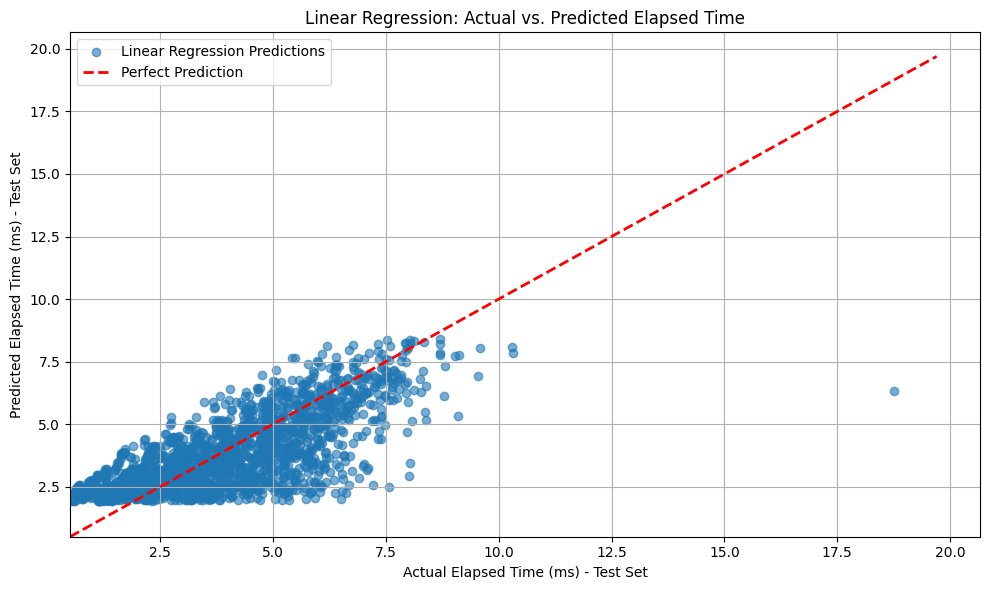

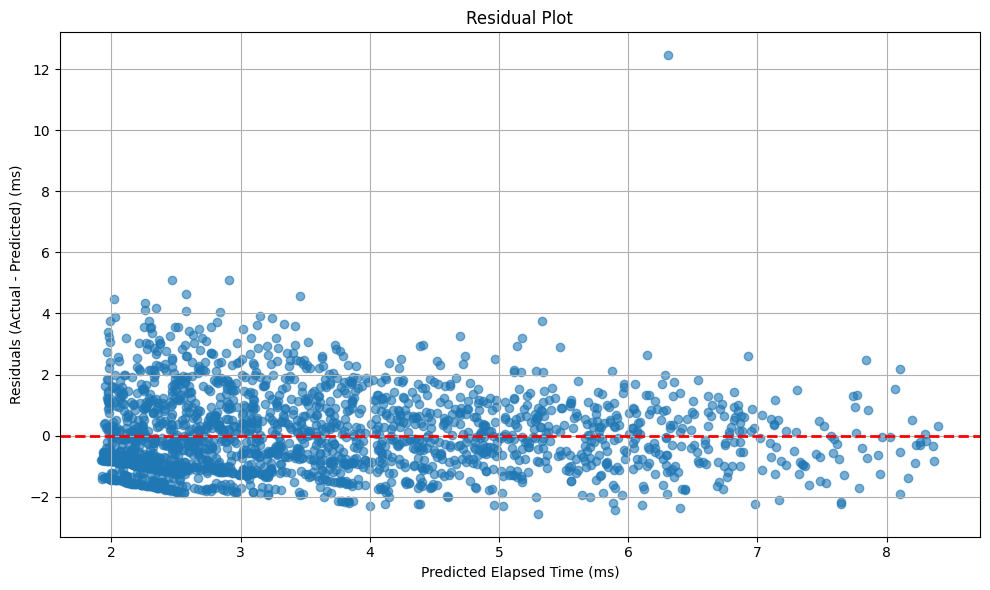

ValueError: X has 1 features, but LinearRegression is expecting 2 features as input.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Assume results_df is already populated from your previous steps ---
# It MUST contain 'elapsed_time' (Actual Time) and 'ideal_time' (Ideal Cost/Time)
# Example creation if needed:
# results_list = [{'elapsed_time': 5.2, 'ideal_time': 1.1, ...}, {...}]
# results_df = pd.DataFrame(results_list)
# -----------------------------------------------------------------------

# Check if DataFrame and necessary columns exist
if "results_df" not in locals() or results_df.empty:
    print("Error: 'results_df' not found or is empty. Please load your results.")
elif not all(col in results_df.columns for col in ["elapsed_time", "ideal_time"]):
    print("Error: 'results_df' must contain 'elapsed_time' and 'ideal_time' columns.")
else:
    # 1. Prepare Data
    # Define feature (X) and target (y)
    feature_column = "ideal_time", "n_rows", "n_cols"
    target_column = "elapsed_time"

    # Drop rows where either feature or target is NaN
    # results_df_clean = results_df.dropna(subset=[feature_column, target_column])

    if results_df_clean.empty:
        print("No valid data points remain after removing NaNs.")
    else:
        print(f"Using {len(results_df_clean)} data points for modeling.")

        # Extract features (X) - needs to be 2D for sklearn
        X = results_df[["ideal_time", "memory_usage"]].values
        # Extract target (y) - needs to be 1D
        y = results_df[target_column].values

        # 2. Split Data into Training and Testing sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"\nTraining set size: {X_train.shape[0]}")
        print(f"Testing set size: {X_test.shape[0]}")

        # 3. Create and Train the Linear Regression Model
        print("\nTraining Linear Regression model...")
        lin_reg_model = LinearRegression()
        lin_reg_model.fit(X_train, y_train)
        print("Training complete.")

        # 4. Get Model Parameters (Coefficients)
        slope = lin_reg_model.coef_[0]
        intercept = lin_reg_model.intercept_

        print("\n--- Linear Regression Model Parameters ---")
        print(f"Equation: Actual_Time ≈ {slope:.4f} * Ideal_Time + {intercept:.4f}")
        print(f"Slope (Coefficient for ideal_time): {slope:.4f}")
        print(f"Intercept (Estimated fixed overhead): {intercept:.4f} ms")
        # Interpretation: For every 1ms increase in ideal calculated time,
        # the actual time increases by approx. {slope:.2f} ms.
        # The baseline time cost (latency) is estimated to be {intercept:.2f} ms.

        # 5. Make Predictions on the Test Set
        y_pred = lin_reg_model.predict(X_test)

        # 6. Evaluate the Model on the Test Set
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)  # Root Mean Squared Error - same units as target
        mae = mean_absolute_error(
            y_test, y_pred
        )  # Mean Absolute Error - same units as target
        r2 = r2_score(y_test, y_pred)

        print("\n--- Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE):      {mse:.4f} (ms^2)")
        print(f"  Root Mean Squared Error (RMSE):{rmse:.4f} (ms)")
        print(f"  Mean Absolute Error (MAE):     {mae:.4f} (ms)")
        print(f"  R-squared (R²):                {r2:.4f}")
        # Interpretation:
        # - RMSE/MAE: On average, the model's predictions are off by about {rmse:.2f}/{mae:.2f} milliseconds.
        # - R²: The ideal time explains about {r2*100:.1f}% of the variance in the actual time.

        # 7. Visualize Predictions vs. Actuals (on Test Set)
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.6, label="Linear Regression Predictions")
        # Add the perfect prediction line (y=x)
        min_val = min(min(y_test), min(y_pred)) * 0.95  # Adjust buffer slightly
        max_val = max(max(y_test), max(y_pred)) * 1.05
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Perfect Prediction",
        )
        plt.xlabel("Actual Elapsed Time (ms) - Test Set")
        plt.ylabel("Predicted Elapsed Time (ms) - Test Set")
        plt.title("Linear Regression: Actual vs. Predicted Elapsed Time")
        plt.legend()
        plt.grid(True)
        plt.xlim(left=min_val)  # Start axis near the minimum value
        plt.ylim(bottom=min_val)
        plt.tight_layout()
        plt.show()

        # Optional: Plot Residuals (Error distribution)
        residuals = y_test - y_pred
        plt.figure(figsize=(10, 6))
        plt.scatter(y_pred, residuals, alpha=0.6)
        plt.axhline(0, color="red", linestyle="--", linewidth=2)
        plt.xlabel("Predicted Elapsed Time (ms)")
        plt.ylabel("Residuals (Actual - Predicted) (ms)")
        plt.title("Residual Plot")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        # Interpretation: Residuals should ideally be randomly scattered around 0 without obvious patterns.

        # --- How to use the trained model for new predictions ---
        # Example: What's the predicted actual time if the ideal time is 2.5 ms?
        new_ideal_time_ms = np.array([[2.5]])  # Must be a 2D array for predict
        predicted_actual_time = lin_reg_model.predict(new_ideal_time_ms)[0]
        print(
            f"\nEstimated actual time for an ideal time of {new_ideal_time_ms[0][0]} ms: {predicted_actual_time:.4f} ms"
        )

Using 5000 data points for modeling.

Training set features shape: (4000, 1)
Testing set features shape: (1000, 1)

Training Linear Regression model (features: ideal_time, memory_gb)...
Training complete.

--- Linear Regression Model Parameters ---
Equation: Actual_Time ≈ (1889.9320 * Ideal_Time) + (0.2504 * Memory_GB) + 0.5026
Coefficient for ideal_time:  1889.9320
Coefficient for memory_gb: 0.2504
Intercept:                 0.5026 ms

--- Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE):      2.7591 (ms^2)
  Root Mean Squared Error (RMSE):1.6611 (ms)
  Mean Absolute Error (MAE):     1.2459 (ms)
  R-squared (R²):                0.9971


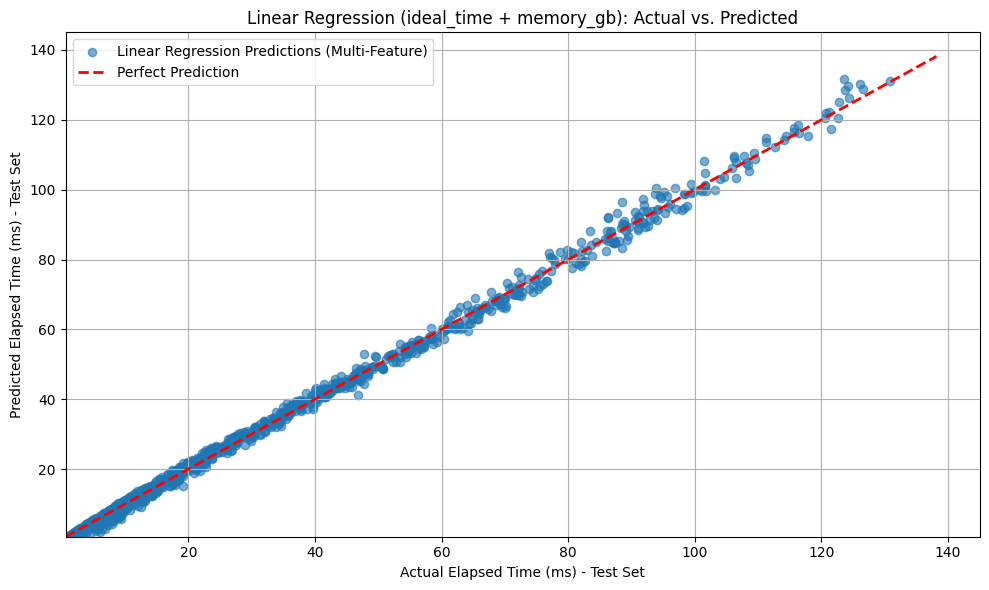

ValueError: X has 2 features, but LinearRegression is expecting 1 features as input.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Assume results_df is already populated ---
# It MUST contain 'elapsed_time', 'ideal_time', and 'memory_gb'
# Example creation if needed:
# results_list = [{'elapsed_time': 5.2, 'ideal_time': 1.1, 'memory_gb': 0.001, ...}, {...}]
# results_df = pd.DataFrame(results_list)
# -----------------------------------------------------------------------

# Check if DataFrame and necessary columns exist
if "results_df" not in locals() or results_df.empty:
    print("Error: 'results_df' not found or is empty. Please load your results.")
elif not all(
    col in results_df.columns for col in ["elapsed_time", "ideal_time", "memory_usage"]
):
    print(
        "Error: 'results_df' must contain 'elapsed_time', 'ideal_time', and 'memory_gb' columns."
    )
else:
    # 1. Prepare Data
    # Define features (X) and target (y)
    feature_columns = ["memory_usage"]  # <<< Added memory_gb
    target_column = "elapsed_time"
    all_columns = feature_columns + [target_column]

    # Drop rows where any required column has NaN
    results_df_clean = results_df.dropna(subset=all_columns)

    if results_df_clean.empty:
        print("No valid data points remain after removing NaNs.")
    else:
        print(f"Using {len(results_df_clean)} data points for modeling.")

        # Extract features (X) - Should be 2D: (n_samples, n_features)
        X = results_df_clean[feature_columns].values
        # Extract target (y) - Should be 1D: (n_samples,)
        y = results_df_clean[target_column].values

        # 2. Split Data into Training and Testing sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"\nTraining set features shape: {X_train.shape}")
        print(f"Testing set features shape: {X_test.shape}")

        # 3. Create and Train the Linear Regression Model
        print("\nTraining Linear Regression model (features: ideal_time, memory_gb)...")
        lin_reg_model_multi = LinearRegression()
        lin_reg_model_multi.fit(X_train, y_train)
        print("Training complete.")

        # 4. Get Model Parameters (Coefficients)
        # The order matches the feature_columns list
        coef_ideal_time = lin_reg_model_multi.coef_[0]
        # coef_memory_gb = lin_reg_model_multi.coef_[1]
        intercept = lin_reg_model_multi.intercept_

        print("\n--- Linear Regression Model Parameters ---")
        print(
            f"Equation: Actual_Time ≈ ({coef_ideal_time:.4f} * Ideal_Time) + ({coef_memory_gb:.4f} * Memory_GB) + {intercept:.4f}"
        )
        print(f"Coefficient for ideal_time:  {coef_ideal_time:.4f}")
        print(f"Coefficient for memory_gb: {coef_memory_gb:.4f}")
        print(f"Intercept:                 {intercept:.4f} ms")

        # 5. Make Predictions on the Test Set
        y_pred = lin_reg_model_multi.predict(X_test)

        # 6. Evaluate the Model on the Test Set
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print("\n--- Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE):      {mse:.4f} (ms^2)")
        print(f"  Root Mean Squared Error (RMSE):{rmse:.4f} (ms)")
        print(f"  Mean Absolute Error (MAE):     {mae:.4f} (ms)")
        print(f"  R-squared (R²):                {r2:.4f}")
        # Compare this R² to the model using only ideal_time. Did it improve much?

        # 7. Visualize Predictions vs. Actuals (on Test Set) - Still useful
        plt.figure(figsize=(10, 6))
        plt.scatter(
            y_test,
            y_pred,
            alpha=0.6,
            label="Linear Regression Predictions (Multi-Feature)",
        )
        min_val = min(min(y_test), min(y_pred)) * 0.95
        max_val = max(max(y_test), max(y_pred)) * 1.05
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Perfect Prediction",
        )
        plt.xlabel("Actual Elapsed Time (ms) - Test Set")
        plt.ylabel("Predicted Elapsed Time (ms) - Test Set")
        plt.title("Linear Regression (ideal_time + memory_gb): Actual vs. Predicted")
        plt.legend()
        plt.grid(True)
        plt.xlim(left=min_val)
        plt.ylim(bottom=min_val)
        plt.tight_layout()
        plt.show()

        # Optional: Residual Plot
        # ... (code for residual plot as before) ...

        # --- How to use the trained model for new predictions ---
        # Example: Predict actual time for ideal=2.5ms and memory=0.0002GB
        new_ideal_time_ms = 2.5
        new_memory_gb = (
            0.0002  # Approx 0.2MB, need to be consistent with ideal_time calculation
        )
        # Create a 2D array with features in the SAME order as training
        new_data_point = np.array([[new_ideal_time_ms, new_memory_gb]])

        predicted_actual_time = lin_reg_model_multi.predict(new_data_point)[0]
        print(
            f"\nEstimated actual time for ideal={new_ideal_time_ms}ms, memory={new_memory_gb}GB: {predicted_actual_time:.4f} ms"
        )

Using 5000 data points for modeling.

Training set features shape: (4000, 3)
Testing set features shape: (1000, 3)

Training Linear Regression model (features: ideal_time, memory_gb)...
Training complete.

--- Linear Regression Model Parameters ---
Equation: Actual_Time ≈ (1874.8269 * Ideal_Time) + (0.2504 * Memory_GB) + -0.0228
Coefficient for ideal_time:  1874.8269
Coefficient for memory_gb: 0.2504
Intercept:                 -0.0228 ms

--- Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE):      2.2815 (ms^2)
  Root Mean Squared Error (RMSE):1.5105 (ms)
  Mean Absolute Error (MAE):     1.0420 (ms)
  R-squared (R²):                0.9976


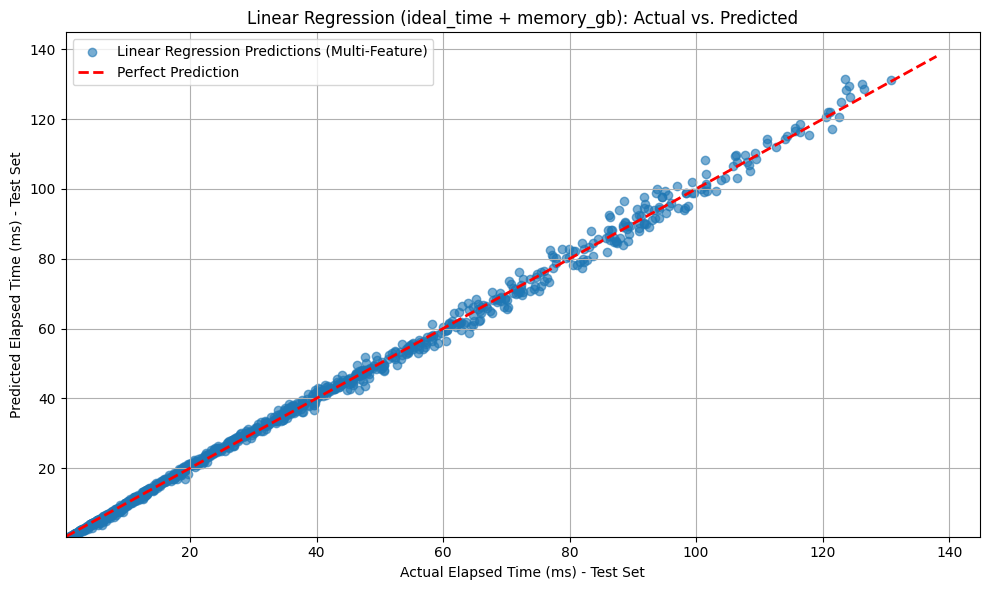

ValueError: X has 2 features, but LinearRegression is expecting 3 features as input.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Assume results_df is already populated ---
# It MUST contain 'elapsed_time', 'ideal_time', and 'memory_gb'
# Example creation if needed:
# results_list = [{'elapsed_time': 5.2, 'ideal_time': 1.1, 'memory_gb': 0.001, ...}, {...}]
# results_df = pd.DataFrame(results_list)
# -----------------------------------------------------------------------

# Check if DataFrame and necessary columns exist
if "results_df" not in locals() or results_df.empty:
    print("Error: 'results_df' not found or is empty. Please load your results.")
elif not all(
    col in results_df.columns for col in ["elapsed_time", "ideal_time", "memory_usage"]
):
    print(
        "Error: 'results_df' must contain 'elapsed_time', 'ideal_time', and 'memory_gb' columns."
    )
else:
    # 1. Prepare Data
    # Define features (X) and target (y)
    feature_columns = ["memory_usage", "n_cols", "n_rows"]  # <<< Added memory_gb
    target_column = "elapsed_time"
    all_columns = feature_columns + [target_column]

    # Drop rows where any required column has NaN
    results_df_clean = results_df.dropna(subset=all_columns)

    if results_df_clean.empty:
        print("No valid data points remain after removing NaNs.")
    else:
        print(f"Using {len(results_df_clean)} data points for modeling.")

        # Extract features (X) - Should be 2D: (n_samples, n_features)
        X = results_df_clean[feature_columns].values
        # Extract target (y) - Should be 1D: (n_samples,)
        y = results_df_clean[target_column].values

        # 2. Split Data into Training and Testing sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"\nTraining set features shape: {X_train.shape}")
        print(f"Testing set features shape: {X_test.shape}")

        # 3. Create and Train the Linear Regression Model
        print("\nTraining Linear Regression model (features: ideal_time, memory_gb)...")
        lin_reg_model_multi = LinearRegression()
        lin_reg_model_multi.fit(X_train, y_train)
        print("Training complete.")

        # 4. Get Model Parameters (Coefficients)
        # The order matches the feature_columns list
        coef_ideal_time = lin_reg_model_multi.coef_[0]
        # coef_memory_gb = lin_reg_model_multi.coef_[1]
        intercept = lin_reg_model_multi.intercept_

        print("\n--- Linear Regression Model Parameters ---")
        print(
            f"Equation: Actual_Time ≈ ({coef_ideal_time:.4f} * Ideal_Time) + ({coef_memory_gb:.4f} * Memory_GB) + {intercept:.4f}"
        )
        print(f"Coefficient for ideal_time:  {coef_ideal_time:.4f}")
        print(f"Coefficient for memory_gb: {coef_memory_gb:.4f}")
        print(f"Intercept:                 {intercept:.4f} ms")

        # 5. Make Predictions on the Test Set
        y_pred = lin_reg_model_multi.predict(X_test)

        # 6. Evaluate the Model on the Test Set
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print("\n--- Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE):      {mse:.4f} (ms^2)")
        print(f"  Root Mean Squared Error (RMSE):{rmse:.4f} (ms)")
        print(f"  Mean Absolute Error (MAE):     {mae:.4f} (ms)")
        print(f"  R-squared (R²):                {r2:.4f}")
        # Compare this R² to the model using only ideal_time. Did it improve much?

        # 7. Visualize Predictions vs. Actuals (on Test Set) - Still useful
        plt.figure(figsize=(10, 6))
        plt.scatter(
            y_test,
            y_pred,
            alpha=0.6,
            label="Linear Regression Predictions (Multi-Feature)",
        )
        min_val = min(min(y_test), min(y_pred)) * 0.95
        max_val = max(max(y_test), max(y_pred)) * 1.05
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Perfect Prediction",
        )
        plt.xlabel("Actual Elapsed Time (ms) - Test Set")
        plt.ylabel("Predicted Elapsed Time (ms) - Test Set")
        plt.title("Linear Regression (ideal_time + memory_gb): Actual vs. Predicted")
        plt.legend()
        plt.grid(True)
        plt.xlim(left=min_val)
        plt.ylim(bottom=min_val)
        plt.tight_layout()
        plt.show()

        # Optional: Residual Plot
        # ... (code for residual plot as before) ...

        # --- How to use the trained model for new predictions ---
        # Example: Predict actual time for ideal=2.5ms and memory=0.0002GB
        new_ideal_time_ms = 2.5
        new_memory_gb = (
            0.0002  # Approx 0.2MB, need to be consistent with ideal_time calculation
        )
        # Create a 2D array with features in the SAME order as training
        new_data_point = np.array([[new_ideal_time_ms, new_memory_gb]])

        predicted_actual_time = lin_reg_model_multi.predict(new_data_point)[0]
        print(
            f"\nEstimated actual time for ideal={new_ideal_time_ms}ms, memory={new_memory_gb}GB: {predicted_actual_time:.4f} ms"
        )